In [1]:
import requests
print("✅ requests library ready")

✅ requests library ready


In [2]:
import requests
import pandas as pd

# CelesTrak's public Starlink TLE data endpoint
url = "https://celestrak.org/NORAD/elements/gp.php?GROUP=starlink&FORMAT=json"

print("Fetching live Starlink satellite data from CelesTrak...")
response = requests.get(url)

if response.status_code == 200:
    data = response.json()
    print(f"✅ Successfully fetched data for {len(data)} Starlink satellites")
else:
    print(f"❌ Request failed with status code: {response.status_code}")

Fetching live Starlink satellite data from CelesTrak...
✅ Successfully fetched data for 10785 Starlink satellites


In [3]:
import requests
import json
import os

url = "https://celestrak.org/NORAD/elements/gp.php?GROUP=starlink&FORMAT=json"
CACHE_FILE = "starlink_data.json"
data = None  # start empty — filled in below

if os.path.exists(CACHE_FILE):
    print("📂 Found a saved copy — loading it instead of downloading again")
    with open(CACHE_FILE, "r") as file:
        data = json.load(file)
else:
    print("🌐 No saved copy yet — downloading from CelesTrak...")
    response = requests.get(url)

    if response.status_code != 200:  # NEW: check before reading it as data
        print(f"❌ Request failed with status code: {response.status_code}")
    else:
        try:                          # NEW: attempt this, catch it if it breaks
            data = response.json()
            with open(CACHE_FILE, "w") as file:
                json.dump(data, file)
        except requests.exceptions.JSONDecodeError:
            print("❌ CelesTrak sent an empty response — likely rate-limited.")
            print("👉 Wait a bit and re-run. This won't happen again once the cache exists.")

if data:
    print(f"✅ Total satellites in dataset: {len(data)}")
else:
    print("⚠️ No data available — see the error above.")

📂 Found a saved copy — loading it instead of downloading again
✅ Total satellites in dataset: 10785


In [4]:
print(len(data))

10785


In [5]:
import json

with open("starlink_data.json", "w") as file:
    json.dump(data, file)

print(f"✅ Saved {len(data)} satellites to starlink_data.json")

✅ Saved 10785 satellites to starlink_data.json


In [6]:
print(data[0])
print(data[0].keys())

{'OBJECT_NAME': 'STARLINK-1008', 'OBJECT_ID': '2019-074B', 'EPOCH': '2026-07-15T18:36:49.706784', 'MEAN_MOTION': 15.53643001, 'ECCENTRICITY': 0.00047433, 'INCLINATION': 53.15, 'RA_OF_ASC_NODE': 291.4766, 'ARG_OF_PERICENTER': 324.0088, 'MEAN_ANOMALY': 36.0603, 'EPHEMERIS_TYPE': 0, 'CLASSIFICATION_TYPE': 'U', 'NORAD_CAT_ID': 44714, 'ELEMENT_SET_NO': 999, 'REV_AT_EPOCH': 36865, 'BSTAR': 0.00067454637, 'MEAN_MOTION_DOT': 0.00043591, 'MEAN_MOTION_DDOT': 0}
dict_keys(['OBJECT_NAME', 'OBJECT_ID', 'EPOCH', 'MEAN_MOTION', 'ECCENTRICITY', 'INCLINATION', 'RA_OF_ASC_NODE', 'ARG_OF_PERICENTER', 'MEAN_ANOMALY', 'EPHEMERIS_TYPE', 'CLASSIFICATION_TYPE', 'NORAD_CAT_ID', 'ELEMENT_SET_NO', 'REV_AT_EPOCH', 'BSTAR', 'MEAN_MOTION_DOT', 'MEAN_MOTION_DDOT'])


In [7]:
import pandas as pd

# Convert the list of satellite dictionaries into rows and columns
df = pd.DataFrame(data)

# Three checks to run on any new dataset, before anything else:
print(df.shape)   # (rows, columns) — should be (10785, 17)
df.info()         # data type + missing values, per column — prints itself
df.head()         # first 5 rows — last line in a cell auto-displays as a table

(10785, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10785 entries, 0 to 10784
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   OBJECT_NAME          10785 non-null  object 
 1   OBJECT_ID            10785 non-null  object 
 2   EPOCH                10785 non-null  object 
 3   MEAN_MOTION          10785 non-null  float64
 4   ECCENTRICITY         10785 non-null  float64
 5   INCLINATION          10785 non-null  float64
 6   RA_OF_ASC_NODE       10785 non-null  float64
 7   ARG_OF_PERICENTER    10785 non-null  float64
 8   MEAN_ANOMALY         10785 non-null  float64
 9   EPHEMERIS_TYPE       10785 non-null  int64  
 10  CLASSIFICATION_TYPE  10785 non-null  object 
 11  NORAD_CAT_ID         10785 non-null  int64  
 12  ELEMENT_SET_NO       10785 non-null  int64  
 13  REV_AT_EPOCH         10785 non-null  int64  
 14  BSTAR                10785 non-null  float64
 15  MEAN_MOTION_DOT      107

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,CLASSIFICATION_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT
0,STARLINK-1008,2019-074B,2026-07-15T18:36:49.706784,15.536430,0.000474,53.1500,291.4766,324.0088,36.0603,0,U,44714,999,36865,0.000675,0.000436,0.0
1,STARLINK-1012,2019-074F,2026-07-16T06:42:52.845120,15.540945,0.000510,53.1542,289.2586,330.4312,29.6410,0,U,44718,999,36872,0.000639,0.000420,0.0
2,STARLINK-1017,2019-074L,2026-07-16T06:38:31.327872,15.342910,0.000093,53.0461,293.3411,90.0887,270.0221,0,U,44723,999,36864,0.000463,0.000153,0.0
3,STARLINK-1020,2019-074N,2026-07-15T17:11:05.343648,15.599962,0.000450,53.1561,314.5042,281.9369,78.1140,0,U,44725,999,36830,0.000860,0.000709,0.0
4,STARLINK-1036,2019-074AE,2026-07-16T05:03:15.387264,15.775640,0.000394,53.0405,276.0719,10.4076,349.7025,0,U,44741,999,36887,0.000284,0.000479,0.0


In [8]:
# Fix: EPOCH is currently just text, not a real date
df['EPOCH'] = pd.to_datetime(df['EPOCH'])

# How many DISTINCT values does each column actually have?
df.nunique()

OBJECT_NAME            10785
OBJECT_ID              10785
EPOCH                   9723
MEAN_MOTION            10468
ECCENTRICITY            8027
INCLINATION              691
RA_OF_ASC_NODE         10767
ARG_OF_PERICENTER      10729
MEAN_ANOMALY           10741
EPHEMERIS_TYPE             1
CLASSIFICATION_TYPE        1
NORAD_CAT_ID           10785
ELEMENT_SET_NO             1
REV_AT_EPOCH            4039
BSTAR                  10781
MEAN_MOTION_DOT         8129
MEAN_MOTION_DDOT          88
dtype: int64

In [9]:
# Drop columns with zero analytical value (confirmed: nunique = 1 for all three)
df = df.drop(columns=['EPHEMERIS_TYPE', 'CLASSIFICATION_TYPE', 'ELEMENT_SET_NO'])

# Check for exact duplicate rows — standard check on any new dataset
print(f"Duplicate rows: {df.duplicated().sum()}")

# Distribution of our two decay-risk signals, before we define any threshold
df[['BSTAR', 'MEAN_MOTION']].describe()

Duplicate rows: 0


,BSTAR,MEAN_MOTION
count,10785.000000,10785.000000
mean,0.000505,15.309826
std,0.007632,0.181724
min,-0.198414,14.910681
25%,0.000020,15.275746
50%,0.000170,15.301847
75%,0.000352,15.343913
max,0.193540,16.333363


Q1: 0.000020  |  Q3: 0.000352  |  IQR: 0.000332
Risk threshold (upper fence): 0.000850
Flagged as at-risk: 897 satellites (8.3% of fleet)


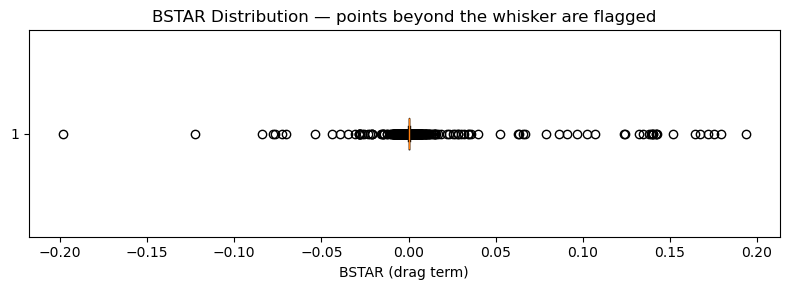

In [10]:
import matplotlib.pyplot as plt

# IQR instead of mean±std — BSTAR is skewed, so percentile-based
# thresholds hold up better than ones built on the mean itself
Q1 = df['BSTAR'].quantile(0.25)
Q3 = df['BSTAR'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR

print(f"Q1: {Q1:.6f}  |  Q3: {Q3:.6f}  |  IQR: {IQR:.6f}")
print(f"Risk threshold (upper fence): {upper_fence:.6f}")

df['decay_risk_flag'] = df['BSTAR'] > upper_fence
flagged = df['decay_risk_flag'].sum()
pct = flagged / len(df) * 100
print(f"Flagged as at-risk: {flagged} satellites ({pct:.1f}% of fleet)")

# Visual gut-check — see the outliers, not just the numbers
plt.figure(figsize=(8, 3))
plt.boxplot(df['BSTAR'], vert=False)
plt.title('BSTAR Distribution — points beyond the whisker are flagged')
plt.xlabel('BSTAR (drag term)')
plt.tight_layout()
plt.show()

In [11]:
# How old is each satellite's orbital fit, right now?
now = pd.Timestamp.now()
df['epoch_age_days'] = (now - df['EPOCH']).dt.total_seconds() / 86400

# Compare: is flagged data noticeably staler than the rest?
df.groupby('decay_risk_flag')['epoch_age_days'].describe()

,count,mean,std,min,25%,50%,75%,max
decay_risk_flag,,,,,,,,
False,9888.0,1.509131,0.277451,0.904619,1.312306,1.406196,1.608802,3.837068
True,897.0,1.417635,0.274298,0.904949,1.299266,1.299266,1.446399,3.450799


In [12]:
# Robust z-score: same idea as a normal z-score (how many "typical
# spread" units above center a value sits), but built on median/IQR
# instead of mean/std -- so it isn't warped by the outliers it's scoring
median_bstar = df['BSTAR'].median()
df['decay_risk_score'] = (df['BSTAR'] - median_bstar) / IQR

# Below-median drag isn't "risk" here -- floor at 0, same logic as before
df['decay_risk_score'] = df['decay_risk_score'].clip(lower=0)

# The actual watchlist: ranked, not just flagged
top_risk = df.sort_values('decay_risk_score', ascending=False)
top_risk[['OBJECT_NAME', 'BSTAR', 'decay_risk_score', 'epoch_age_days']].head(10)

,OBJECT_NAME,BSTAR,decay_risk_score,epoch_age_days
7652,STARLINK-34965,0.193540,582.480029,1.299266
7646,STARLINK-34862,0.179050,538.830414,1.299266
7712,STARLINK-34987,0.175167,527.133537,1.299266
7700,STARLINK-34982,0.171675,516.615746,1.299266
7696,STARLINK-34964,0.167069,502.742817,1.299266
7649,STARLINK-34939,0.164649,495.451630,1.299266
7697,STARLINK-34953,0.151916,457.096530,1.299266
7643,STARLINK-34967,0.142671,429.248860,1.299266
7647,STARLINK-34942,0.142191,427.802195,1.299266
7648,STARLINK-34944,0.141808,426.648623,1.299266


In [13]:
# The real "how young is this satellite" signal — low REV_AT_EPOCH = recently launched
top_risk[['OBJECT_NAME', 'OBJECT_ID', 'BSTAR', 'REV_AT_EPOCH', 'MEAN_MOTION']].head(10)

# Zoom out: is this a top-10 quirk, or does the whole flagged group skew this way?
df.groupby('decay_risk_flag')['REV_AT_EPOCH'].describe()

,count,mean,std,min,25%,50%,75%,max
decay_risk_flag,,,,,,,,
False,9888.0,11004.413329,8526.372487,197.0,3849.0,9206.0,16980.0,37003.0
True,897.0,4975.924192,7425.935285,321.0,576.0,582.0,7979.0,36830.0


In [14]:
top_risk[['OBJECT_NAME', 'OBJECT_ID', 'BSTAR', 'REV_AT_EPOCH', 'MEAN_MOTION']].head(10)

,OBJECT_NAME,OBJECT_ID,BSTAR,REV_AT_EPOCH,MEAN_MOTION
7652,STARLINK-34965,2025-175N,0.193540,579,15.143043
7646,STARLINK-34862,2025-175G,0.179050,573,15.157871
7712,STARLINK-34987,2025-179W,0.175167,579,15.162544
7700,STARLINK-34982,2025-179J,0.171675,579,15.170206
7696,STARLINK-34964,2025-179E,0.167069,579,15.237569
7649,STARLINK-34939,2025-175K,0.164649,579,15.169392
7697,STARLINK-34953,2025-179F,0.151916,579,15.187276
7643,STARLINK-34967,2025-175D,0.142671,579,15.198958
7647,STARLINK-34942,2025-175H,0.142191,578,15.205346
7648,STARLINK-34944,2025-175J,0.141808,563,15.129346


In [15]:
# 1000 revolutions is a rough cutoff — comfortably past the ~580 new-satellite
# cluster, well below the established group. We'll tighten it once we see the split.
still_climbing = df[(df['decay_risk_flag']) & (df['REV_AT_EPOCH'] < 1000)]
established_risk = df[(df['decay_risk_flag']) & (df['REV_AT_EPOCH'] >= 1000)]

print(f"Flagged, likely still climbing: {len(still_climbing)}")
print(f"Flagged AND established (the real watchlist): {len(established_risk)}")

established_risk[['OBJECT_NAME', 'BSTAR', 'REV_AT_EPOCH']].sort_values('BSTAR', ascending=False).head(10)

Flagged, likely still climbing: 546
Flagged AND established (the real watchlist): 351


,OBJECT_NAME,BSTAR,REV_AT_EPOCH
7704,STARLINK-34923,0.063396,5108
7706,STARLINK-34925,0.039608,5115
8013,STARLINK-35176,0.031709,4639
7650,STARLINK-34947,0.028496,5199
8019,STARLINK-35351,0.026880,4638
7705,STARLINK-34962,0.025444,5117
7582,STARLINK-34614,0.023131,5501
1023,STARLINK-3555,0.021815,24252
7662,STARLINK-34927,0.018880,5198
8074,STARLINK-34894,0.016975,4619


In [16]:
# Is established_risk one real group, or a second hidden age cluster?
established_risk['REV_AT_EPOCH'].describe()

# Does BSTAR still just track age, even inside 'established'?
established_risk[['REV_AT_EPOCH', 'BSTAR']].corr()

,REV_AT_EPOCH,BSTAR
REV_AT_EPOCH,1.000000,0.014111
BSTAR,0.014111,1.000000


In [17]:
established_risk['REV_AT_EPOCH'].describe()

count      351.000000
mean     11831.512821
std       7983.058947
min       1191.000000
25%       7039.000000
50%       8399.000000
75%      14324.500000
max      36830.000000
Name: REV_AT_EPOCH, dtype: float64

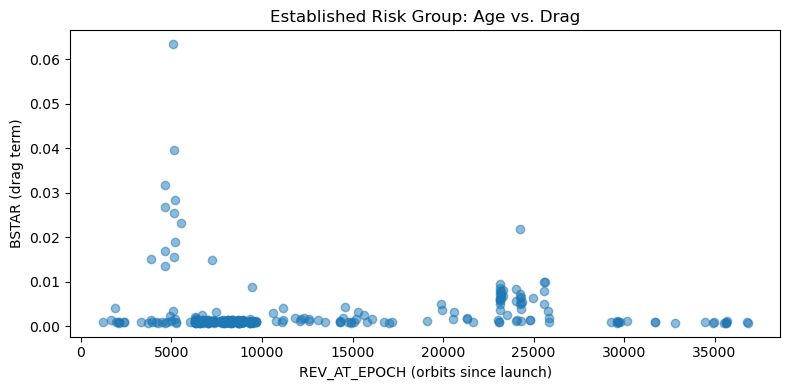

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.scatter(established_risk['REV_AT_EPOCH'], established_risk['BSTAR'], alpha=0.5)
plt.xlabel('REV_AT_EPOCH (orbits since launch)')
plt.ylabel('BSTAR (drag term)')
plt.title('Established Risk Group: Age vs. Drag')
plt.tight_layout()
plt.show()

In [19]:
# Isolate the cluster the plot just revealed
batch_cluster = established_risk[
    (established_risk['REV_AT_EPOCH'] >= 4000) & (established_risk['REV_AT_EPOCH'] <= 6000)
]

print(f"Satellites in this band: {len(batch_cluster)}")
batch_cluster[['OBJECT_NAME', 'OBJECT_ID', 'REV_AT_EPOCH', 'MEAN_MOTION', 'BSTAR']] \
    .sort_values('BSTAR', ascending=False)

Satellites in this band: 22


,OBJECT_NAME,OBJECT_ID,REV_AT_EPOCH,MEAN_MOTION,BSTAR
7704,STARLINK-34923,2025-179N,5108,15.183607,0.063396
7706,STARLINK-34925,2025-179Q,5115,15.080025,0.039608
8013,STARLINK-35176,2025-211L,4639,15.074000,0.031709
7650,STARLINK-34947,2025-175L,5199,15.071856,0.028496
8019,STARLINK-35351,2025-211S,4638,15.070975,0.026880
7705,STARLINK-34962,2025-179P,5117,15.098300,0.025444
7582,STARLINK-34614,2025-161R,5501,15.328289,0.023131
7662,STARLINK-34927,2025-175Y,5198,15.066188,0.018880
8074,STARLINK-34894,2025-216V,4619,15.329111,0.016975
7714,STARLINK-34966,2025-179Y,5114,15.064436,0.015572


In [20]:
# Final, validated watchlist
final_watchlist = established_risk.sort_values('decay_risk_score', ascending=False)

# Export both: full df for transparency/reproducibility, watchlist as the actual deliverable
final_watchlist.to_csv('starlink_decay_watchlist.csv', index=False)  # index=False: skip writing pandas' row numbers as a junk column
df.to_csv('starlink_cleaned_full.csv', index=False)

print(f"Final watchlist: {len(final_watchlist)} satellites")
print("Saved: starlink_decay_watchlist.csv, starlink_cleaned_full.csv")

Final watchlist: 351 satellites
Saved: starlink_decay_watchlist.csv, starlink_cleaned_full.csv


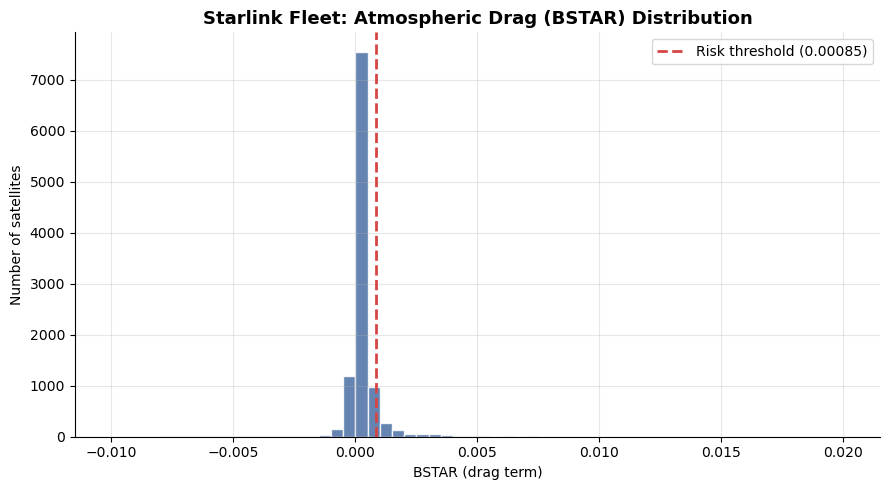

In [21]:
import matplotlib.pyplot as plt

# One-time style setup — applies to every chart below, consistent professional look
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 10

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df['BSTAR'], bins=60, range=(-0.01, 0.02), color='#4A6FA5', edgecolor='white', alpha=0.85)
ax.axvline(upper_fence, color='#D64545', linestyle='--', linewidth=2,
           label=f'Risk threshold ({upper_fence:.5f})')
ax.set_title('Starlink Fleet: Atmospheric Drag (BSTAR) Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('BSTAR (drag term)')
ax.set_ylabel('Number of satellites')
ax.legend()
plt.tight_layout()
plt.savefig('chart1_bstar_distribution.png', dpi=150)
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_4564\1583805303.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=labels, patch_artist=True, widths=0.5)


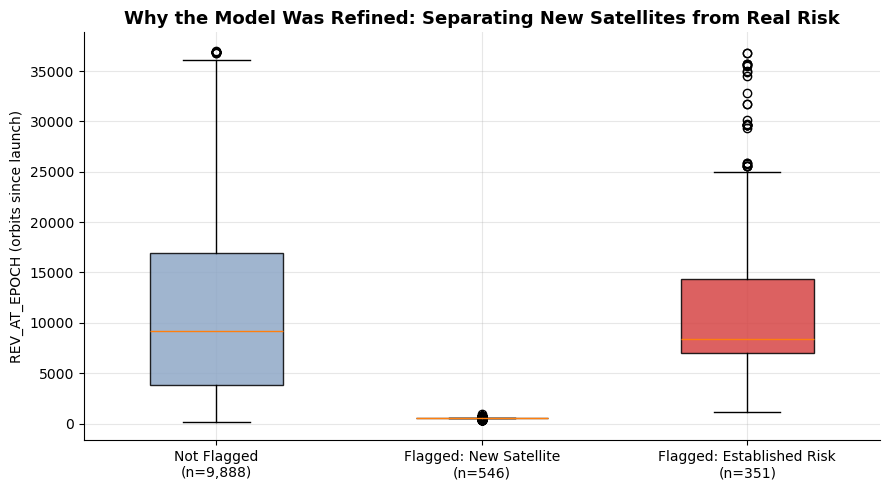

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))

groups = [df.loc[~df['decay_risk_flag'], 'REV_AT_EPOCH'],
          still_climbing['REV_AT_EPOCH'],
          established_risk['REV_AT_EPOCH']]
labels = [f'Not Flagged\n(n={len(df) - df["decay_risk_flag"].sum():,})',
          f'Flagged: New Satellite\n(n={len(still_climbing)})',
          f'Flagged: Established Risk\n(n={len(established_risk)})']

bp = ax.boxplot(groups, labels=labels, patch_artist=True, widths=0.5)
for patch, color in zip(bp['boxes'], ['#8FA8C7', '#F2B84B', '#D64545']):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

ax.set_ylabel('REV_AT_EPOCH (orbits since launch)')
ax.set_title('Why the Model Was Refined: Separating New Satellites from Real Risk', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart2_confound_reveal.png', dpi=150)
plt.show()

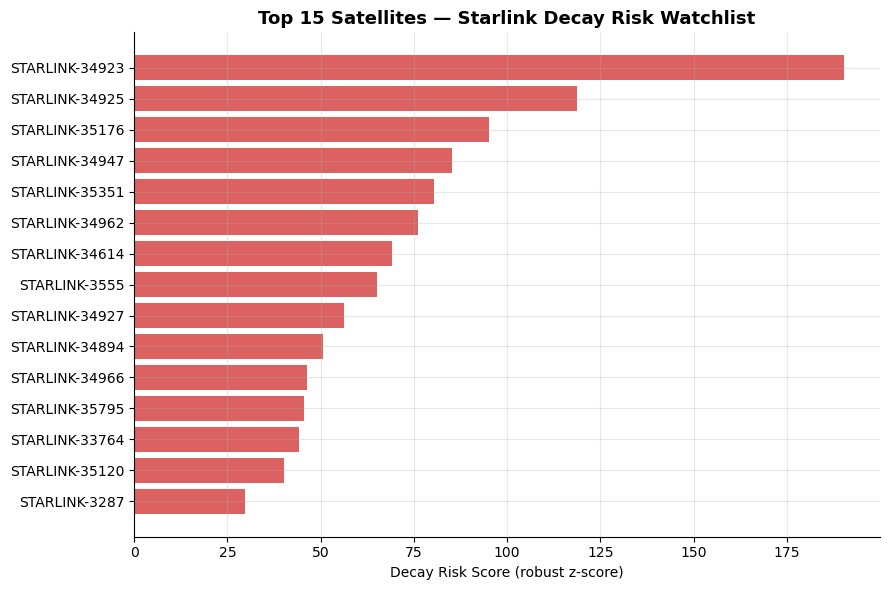

In [23]:
fig, ax = plt.subplots(figsize=(9, 6))

top15 = final_watchlist.head(15).sort_values('decay_risk_score')  # ascending so #1 lands on top
ax.barh(top15['OBJECT_NAME'], top15['decay_risk_score'], color='#D64545', alpha=0.85)

ax.set_xlabel('Decay Risk Score (robust z-score)')
ax.set_title('Top 15 Satellites — Starlink Decay Risk Watchlist', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart3_top15_watchlist.png', dpi=150)
plt.show()